# Ecommerce Furniture Dataset 2024 - Project 2

### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [2]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Loading Dataset

In [3]:
df = pd.read_csv("ecommerce_furniture_dataset_2024.csv")
df.head(2)

,productTitle,originalPrice,price,sold,tagText
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,NaN,$46.79,600,Free shipping
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,NaN,$169.72,0,Free shipping


In [4]:
df.shape

(2000, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   productTitle   2000 non-null   object
 1   originalPrice  487 non-null    object
 2   price          2000 non-null   object
 3   sold           2000 non-null   int64 
 4   tagText        1997 non-null   object
dtypes: int64(1), object(4)
memory usage: 78.3+ KB


In [6]:
df.isnull().sum()

productTitle        0
originalPrice    1513
price               0
sold                0
tagText             3
dtype: int64

In [7]:
df.describe()

,sold
count,2000.000000
mean,23.493500
std,254.094061
min,0.000000
25%,1.000000
50%,3.000000
75%,9.000000
max,10000.000000


In [8]:
df.duplicated().sum() 

np.int64(94)

#### Data Preprocessing 

In [9]:
df = df.drop_duplicates()

In [10]:
df["price"] = df["price"].replace('[$,]', '', regex=True).astype(float)

In [11]:
df["originalPrice"] = df["originalPrice"].replace('[$,]', '', regex=True).astype(float)

In [12]:
df["originalPrice"] = df["originalPrice"].fillna(df["originalPrice"].median())

In [13]:
df['tagText'] = df['tagText'].fillna('No Tag')

In [14]:
df.head()

,productTitle,originalPrice,price,sold,tagText
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,87.155,46.79,600,Free shipping
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,87.155,169.72,0,Free shipping
2,Desser For Bedroom With 7 Fabric Drawers Organ...,78.400,39.46,7,Free shipping
3,"Modern Accent Boucle Chair,Upholstered Tufted ...",87.155,111.99,0,Free shipping
4,Small Unit Simple Computer Desk Household Wood...,48.820,21.37,1,Free shipping


In [15]:
df.isnull().sum()

productTitle     0
originalPrice    0
price            0
sold             0
tagText          0
dtype: int64

#### Exploratory Data Analysis(EDA)

Ques 1. What is the distribution of product price?

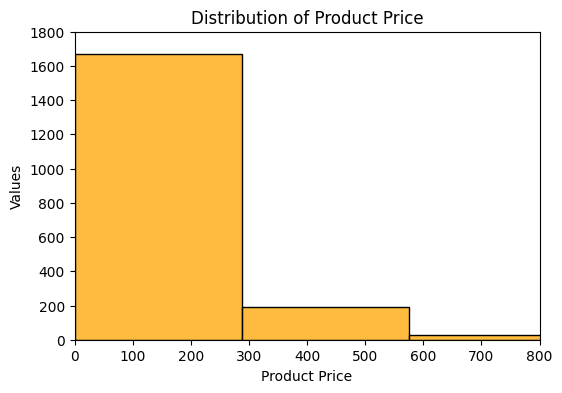

In [47]:
plt.figure(figsize = (6,4))
sns.histplot(df['price'], bins = 10, color= 'orange')
plt.title('Distribution of Product Price')
plt.xlabel('Product Price')
plt.ylabel('Values')
plt.xlim(0,800)
plt.ylim(0,1800)
plt.show()

Observation:
The product price distribution is right-skewed, with most items in the lower range and few high-priced outliers

Ques 2. What is the relationship between price and sold items?

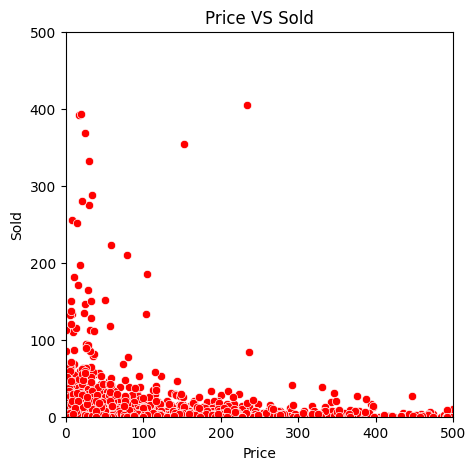

In [53]:
plt.figure(figsize = (5,5))
sns.scatterplot(x = df['price'], y = df['sold'], color ='red')
plt.title('Price VS Sold')
plt.xlabel('Price')
plt.ylabel('Sold')
plt.xlim(0, 500)
plt.ylim(0,500)
plt.show()

Observation:
Most products have low prices and sales, showing that higher-priced items generally sell fewer units.



Ques 3. Which tag appear most frequently ?

In [19]:
df['tagText'].value_counts().idxmax()

'Free shipping'

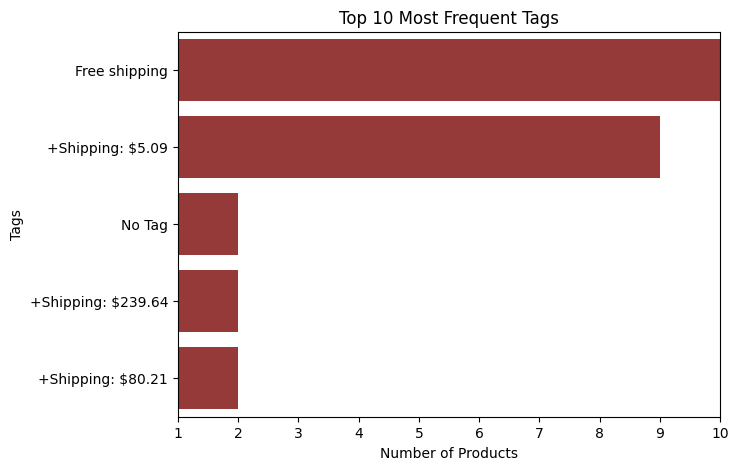

In [20]:
top_tags = df['tagText'].value_counts().head()
plt.figure(figsize = (7,5))
sns.barplot(x=top_tags.values, y=top_tags.index, color = 'brown')
plt.xlabel("Number of Products")
plt.ylabel("Tags")
plt.xlim(1,10)
plt.title("Top 10 Most Frequent Tags")
plt.show()

Observation:
The most frequent product tags are concentrated among a few categories, with the top tags appearing in 1–10 products each. 

"Free shipping" is the most frequently appear from top 10 tags.

Ques 4. Which products have the highest sales ?

In [21]:
stop_words = set(stopwords.words('english'))

def extract_keyword(title):
    words = word_tokenize(title.lower())
    words = [w for w in words if w.isalpha() and w not in stop_words]
    return words[0] if words else None
    
df["main_product"] = df["productTitle"].apply(extract_keyword)
df.head(10)

,productTitle,originalPrice,price,sold,tagText,main_product
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,87.155,46.79,600,Free shipping,dresser
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,87.155,169.72,0,Free shipping,outdoor
2,Desser For Bedroom With 7 Fabric Drawers Organ...,78.400,39.46,7,Free shipping,desser
3,"Modern Accent Boucle Chair,Upholstered Tufted ...",87.155,111.99,0,Free shipping,modern
4,Small Unit Simple Computer Desk Household Wood...,48.820,21.37,1,Free shipping,small
5,"3 Pieces Patio Furniture Set, Outdoor Swivel G...",1294.040,123.40,53,Free shipping,pieces
6,5-Piece Patio Furniture Set Outdoor Couch with...,87.155,198.31,1,Free shipping,patio
7,"Living Room Furniture, Modern 3-Piece Includin...",1474.170,734.58,5,Free shipping,living
8,TV Stand Dresser For Bedroom With 5 Fabric Dra...,87.155,43.96,3,No Tag,tv
9,Outdoor Furniture Set 3 Pieces Wicker Patio Fu...,87.155,233.30,0,Free shipping,outdoor


In [22]:
df_sale = df.groupby('main_product')['sold'].sum().reset_index()

In [55]:
df_sale = df_sale.sort_values(by='sold', ascending=False).head(10)

C:\Users\User\AppData\Local\Temp\ipykernel_18372\2929983894.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sold', y='main_product', data=df_sale, palette='viridis')


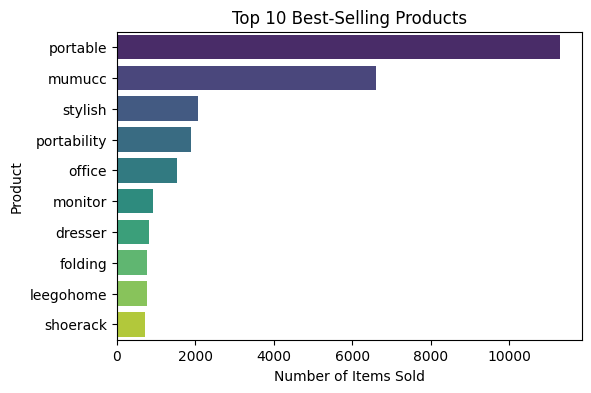

In [24]:
plt.figure(figsize = (6,4))
sns.barplot(x='sold', y='main_product', data=df_sale, palette='viridis')
plt.xlabel("Number of Items Sold")
plt.ylabel("Product")
plt.title("Top 10 Best-Selling Products")
plt.show() 

Observation:
Showing top 10 product sales, where portable type product has highest sale.

#### Feature Engineering

In [25]:
df["discount_percent"] = ((df["originalPrice"] - df["price"]) / df["originalPrice"]) * 100

In [26]:
df["price_diff"] = df["originalPrice"] - df["price"]

In [27]:
df.head()

,productTitle,originalPrice,price,sold,tagText,main_product,discount_percent,price_diff
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,87.155,46.79,600,Free shipping,dresser,46.314038,40.365
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,87.155,169.72,0,Free shipping,outdoor,-94.733521,-82.565
2,Desser For Bedroom With 7 Fabric Drawers Organ...,78.400,39.46,7,Free shipping,desser,49.668367,38.940
3,"Modern Accent Boucle Chair,Upholstered Tufted ...",87.155,111.99,0,Free shipping,modern,-28.495210,-24.835
4,Small Unit Simple Computer Desk Household Wood...,48.820,21.37,1,Free shipping,small,56.226956,27.450


In [28]:
le = LabelEncoder()
df['tagText']= le.fit_transform(df['tagText'])
df['productTitle'] = le.fit_transform(df['productTitle'])
df['main_product'] = le.fit_transform(df['main_product']) 
df.head()

,productTitle,originalPrice,price,sold,tagText,main_product,discount_percent,price_diff
0,543,87.155,46.79,600,99,112,46.314038,40.365
1,1242,87.155,169.72,0,99,314,-94.733521,-82.565
2,503,78.400,39.46,7,99,99,49.668367,38.940
3,1054,87.155,111.99,0,99,278,-28.495210,-24.835
4,1509,48.820,21.37,1,99,390,56.226956,27.450


In [29]:
df.columns

Index(['productTitle', 'originalPrice', 'price', 'sold', 'tagText',
       'main_product', 'discount_percent', 'price_diff'],
      dtype='object')

#### Model Building and Training

In [38]:
x = df.drop(columns = ['price'], axis = 1)
y = df['price'] 

In [39]:
x_train,x_test, y_train, y_test = train_test_split(x,y, random_state = 42, test_size = 0.2)

In [40]:
x_train.shape

(1524, 7)

In [41]:
x_test.shape

(382, 7)

In [42]:
rf = RandomForestRegressor(n_estimators = 200, random_state = 42, max_depth = 10)
rf.fit(x_train, y_train) 

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
y_predict = model.predict(x_test)
y_pred = rf.predict(x_test)
print('MSE of rf:', mean_squared_error(y_test, y_pred))
print('MSE of model:', mean_squared_error(y_test, y_predict)) 

MSE of rf: 656.4363146846398
MSE of model: 5.98363979515644e-26


In [45]:
print('R2 of rf:', round(r2_score(y_test, y_pred),3))
print('R2 of model:', (r2_score(y_test, y_predict)))

R2 of rf: 0.974
R2 of model: 1.0
